<a href="https://colab.research.google.com/github/Gunasalini/student-performance-data-science/blob/main/Week_1_Data_Acquisition_Cleaning_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))

['student.zip', '.student.zip_old']


In [3]:
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print(os.listdir("student_data/extracted"))

['student-por.csv', 'student-mat.csv', 'student-merge.R', 'student.txt']


In [4]:
import pandas as pd

df = pd.read_csv("student_data/extracted/student-mat.csv", sep=";")

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
print("Dataset shape:", df.shape)
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(df.columns.tolist())

Dataset shape: (395, 33)

Number of rows: 395
Number of columns: 33
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
missing_values = df.isnull().sum()

print(missing_values)
print("Total missing values:", missing_values.sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Total missing values: 0


In [10]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [20]:
cleaned_df = df.copy()
cleaned_df = cleaned_df.drop_duplicates()
print("Missing values after cleaning:", cleaned_df.isnull().sum().sum())
print("Duplicate rows after cleaning:", cleaned_df.duplicated().sum())
print("\nOriginal dataset shape:", df.shape)
print("Cleaned dataset shape:", cleaned_df.shape)
print(cleaned_df.dtypes)
cleaned_df.describe()

Missing values after cleaning: 0
Duplicate rows after cleaning: 0

Original dataset shape: (395, 33)
Cleaned dataset shape: (395, 33)
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

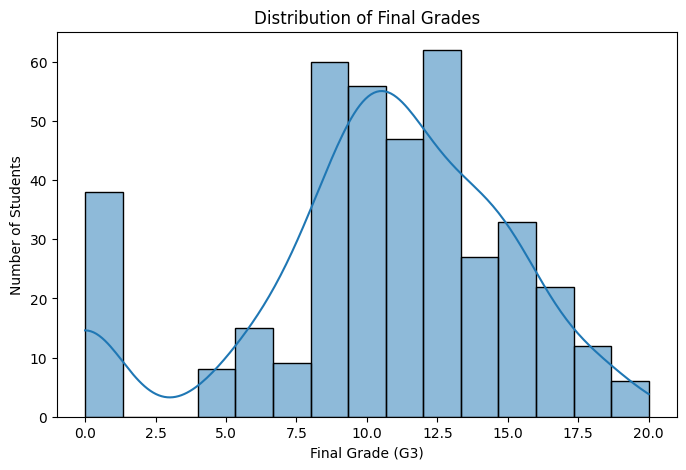

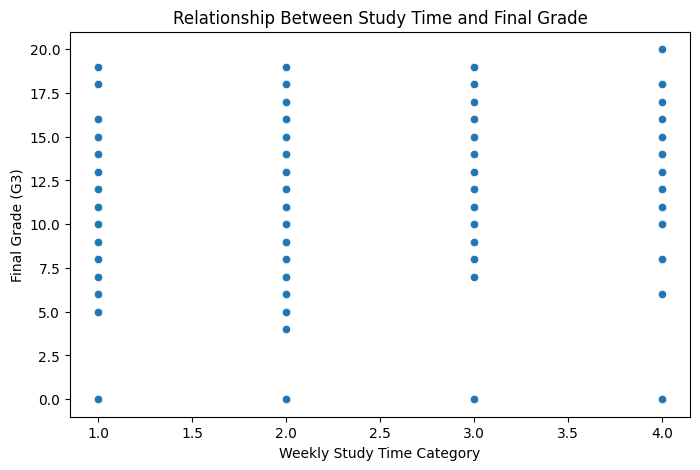

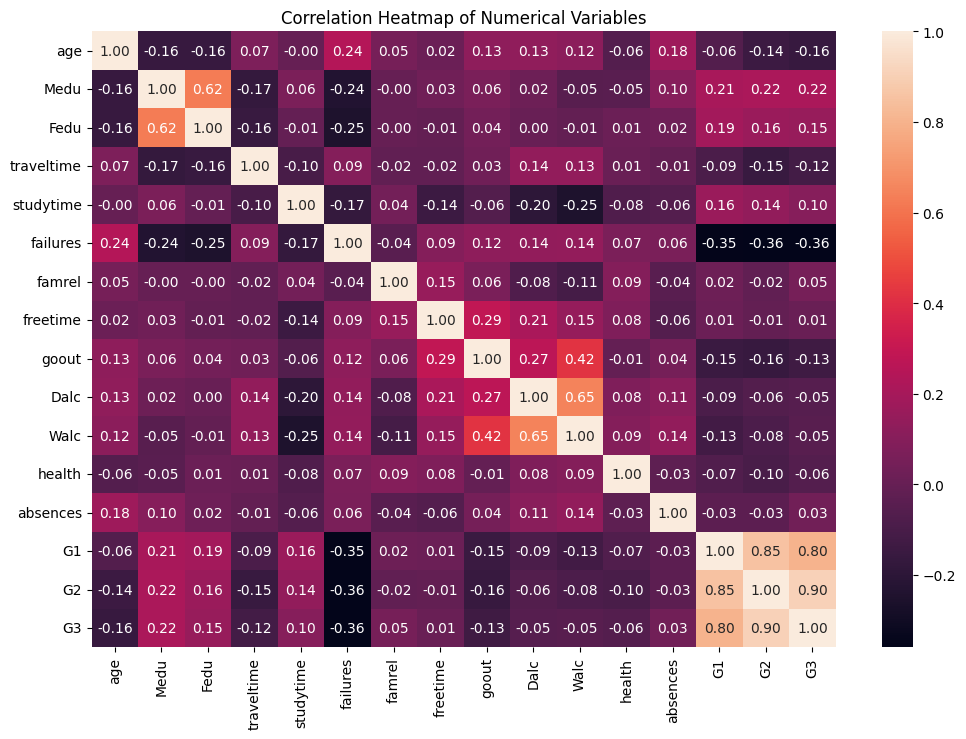

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["G3"], bins=15, kde=True)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=cleaned_df,
    x="studytime",
    y="G3"
)

plt.title("Relationship Between Study Time and Final Grade")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.show()
numerical_columns = cleaned_df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numerical_columns.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

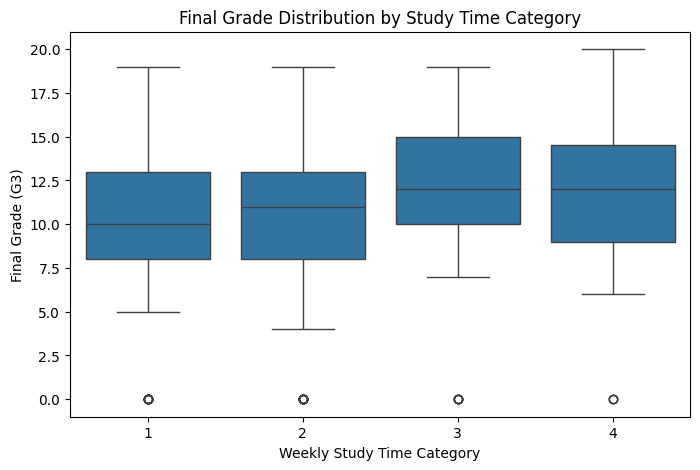

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cleaned_df,
    x="studytime",
    y="G3"
)

plt.title("Final Grade Distribution by Study Time Category")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.show()